<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

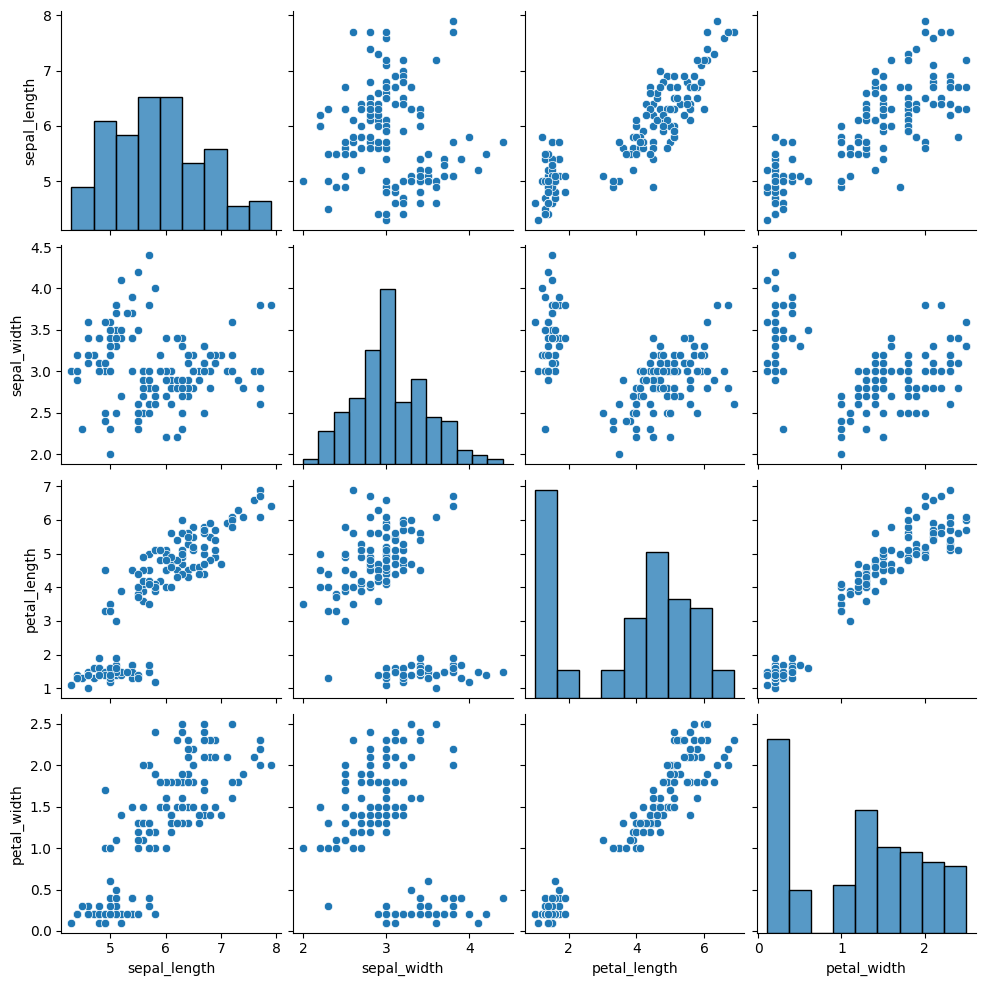

In [50]:
import pandas as pd
import numpy as np
data_source = 'iris.csv'
d = pd.read_table(data_source, delimiter=',')
d.head()
import seaborn as sb
%matplotlib inline
sb.pairplot(d)


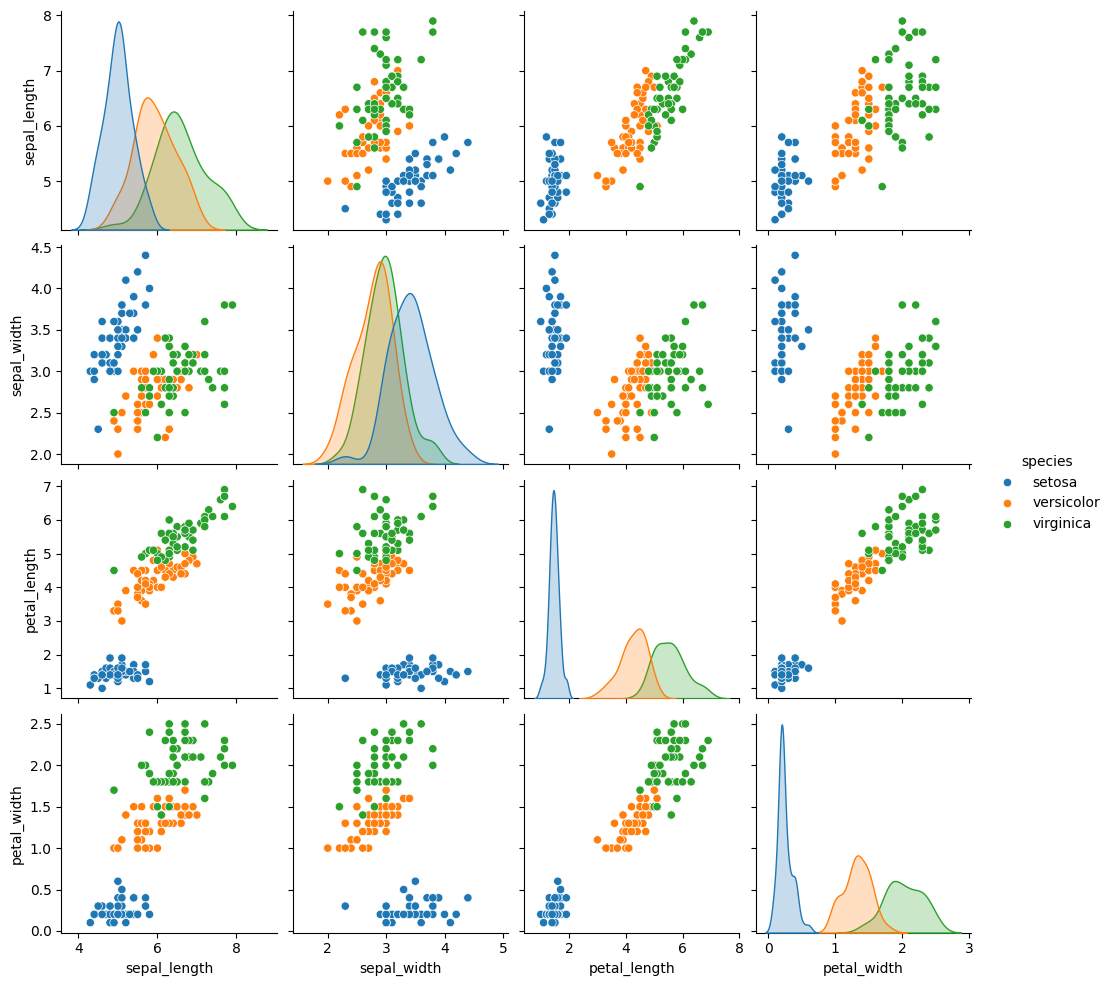

In [33]:
import pandas as pd
import numpy as np
data_source = 'iris.csv'
d = pd.read_table(data_source, delimiter=',')
d.head()
import seaborn as sb
%matplotlib inline
sb.pairplot(d, hue='species')

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train = d[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_train = d['species']

K = 3

knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X_train, y_train)

X_test = np.array([[1.2, 1.0, 2.8, 1.2]])
target = knn.predict(X_test)
print(target)

['versicolor']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_holdout, y_train, y_holdout = \
    train_test_split(d[['sepal_length','sepal_width',
                        'petal_length', 'petal_width']],
                     d['species'],
                     test_size=0.3,
                     random_state=17)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_holdout)
accur = accuracy_score(y_holdout, knn_pred)
print('accuracy: ', accur)

accuracy:  0.9777777777777777


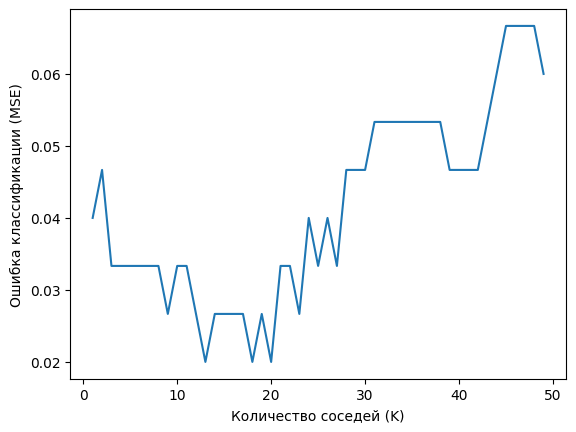

Оптимальные значения K:  [13, 18, 20]


In [21]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

k_list = list(range(1,50))
# Пустой список для хранения значений точности
cv_scores = []
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, d.iloc[:, 0:4], d['species'], cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# Вычисляем ошибку
MSE = [1-x for x in cv_scores]

plt.plot(k_list, MSE)
plt.xlabel('Количество соседей (K)');
plt.ylabel('Ошибка классификации (MSE)')
plt.show()

# Ищем минимум
k_min = min(MSE)

# Пробуем найти прочие минимумы (если их несколько)
all_k_min = []
for i in range(len(MSE)):
    if MSE[i] <= k_min:
        all_k_min.append(k_list[i])

print('Оптимальные значения K: ', all_k_min)

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Загрузка датасета
cancer = load_breast_cancer()
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data['target'] = cancer.target

display(data.head())

data.info()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

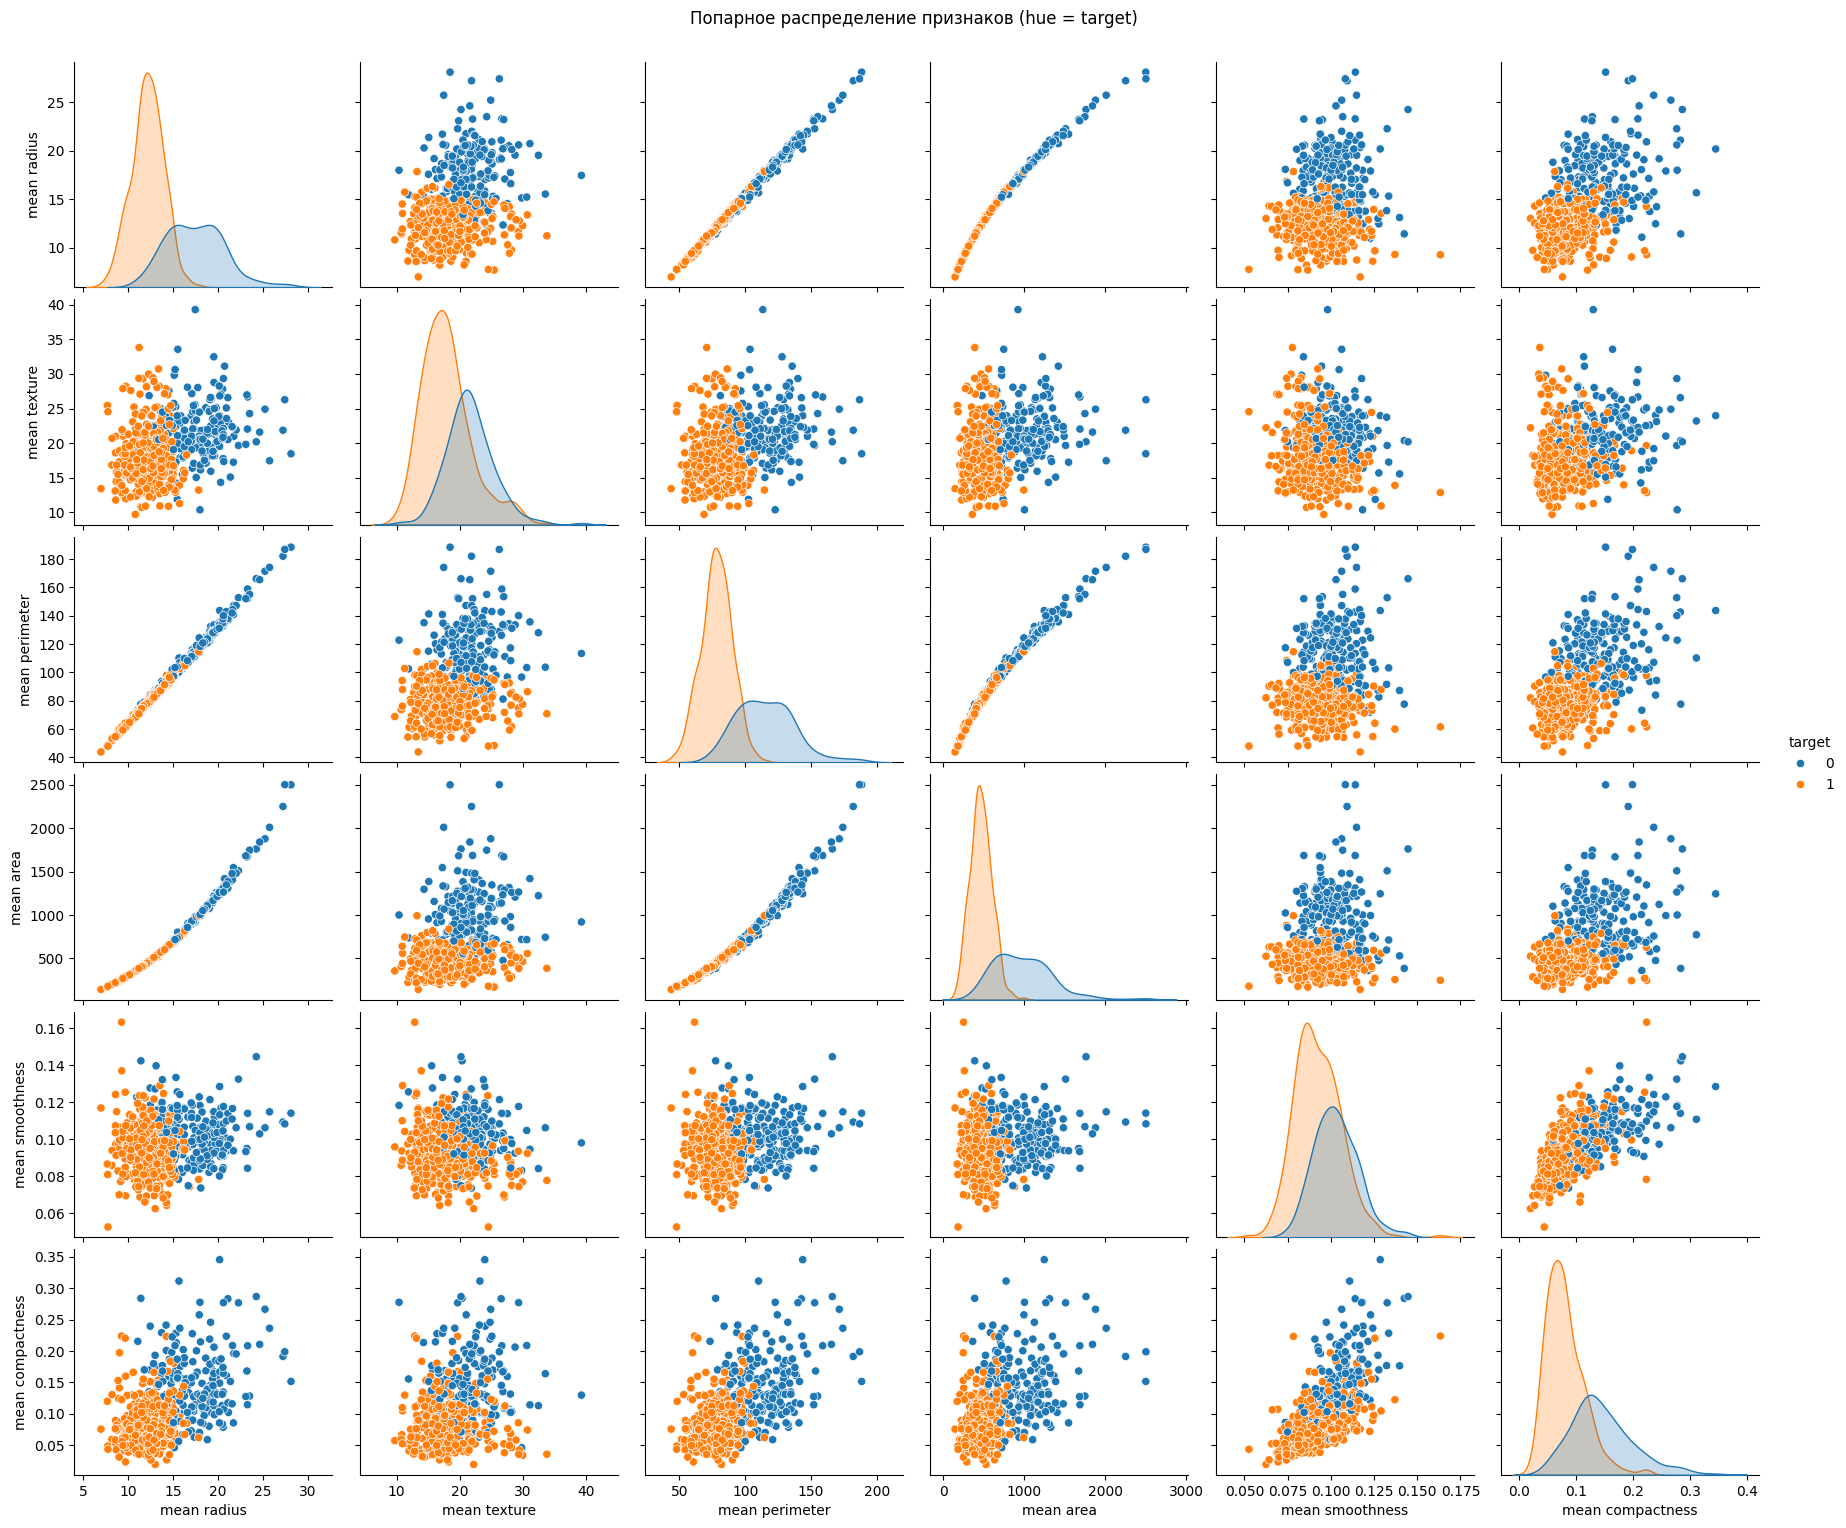

In [39]:
# Выберем несколько наиболее информативных признаков для визуализации
features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
            'mean smoothness', 'mean compactness']

sns.pairplot(data[features + ['target']], hue='target', height=2.5, aspect=1.2)
plt.suptitle('Попарное распределение признаков (hue = target)', y=1.02)
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=17)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели при k=3: {accuracy:.4f}')

Точность модели при k=3: 0.9064


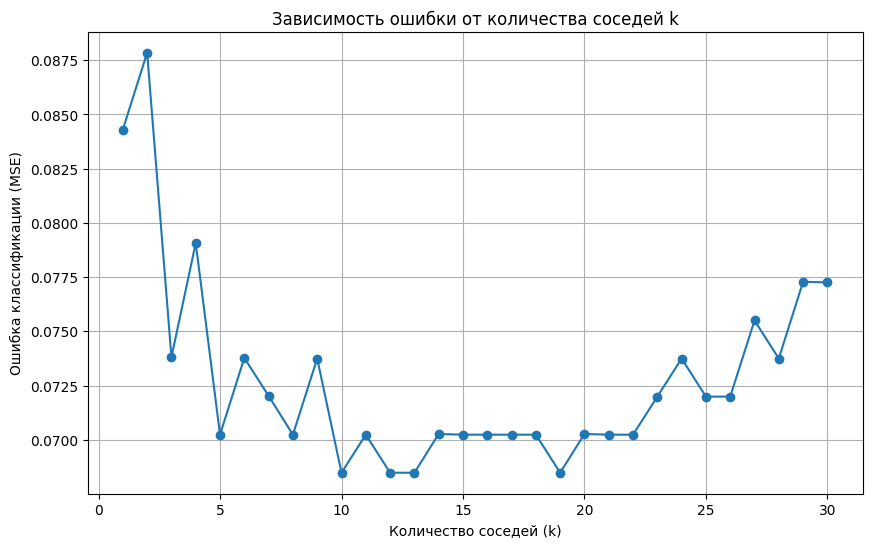

In [47]:
k_list = list(range(1, 31))
cv_scores = []

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

MSE = [1 - x for x in cv_scores]

plt.figure(figsize=(10, 6))
plt.plot(k_list, MSE, marker='o')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Ошибка классификации (MSE)')
plt.title('Зависимость ошибки от количества соседей k')
plt.grid(True)
plt.show()



In [49]:
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)
y_pred_opt = knn_optimal.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_opt)
print(f'Точность модели с оптимальным k = {optimal_k}: {final_accuracy:.4f}')

Точность модели с оптимальным k = 10: 0.9298
